## Example for pairing IAGOS data with UFS-AQM

This example demonstrates how to use MELODIES MONET to pair aircraft observations from IAGOS (https://www.iagos.org/) to model output from the UFS-AQM for a single flight. Loop pairing following the AEROMMA examples can be used.

This example uses the flight timeseries IAGOS data rather than the profile data, though it will work with either format. There may be more than one IAGOS flight collecting data at a time and so right now it is recommended to set up the pairing to only process one flight at a time. Resulting from this potential time alignment, use of the plotting and statistics auto-generation tools for multiple flights is limited.

### First, import the driver and initiate the analysis class

In [1]:
from melodies_monet import driver

an = driver.analysis()

### Second, we read in a control file

This control file must include renaming of some variables for both models and IAGOS observations. The model section should rename "press_pa_mid" to "pressure_model". The observation section should rename lat, lon, UTC_time, air_press_AC, and baro_alt_AC to the more standard names of "latitude", "longitude", "time", "pressure_obs", and "altitude".

In [2]:
an.control = '/scratch3/BMC/rcm2/mbruckner/melodies/MELODIES-MONET/examples/yaml/control_iagos_AEROMMA_UFSAQM.yaml'
an.read_control()

### Load the model and observation data

In [3]:
an.open_models()

ufs
/scratch3/BMC/rcm2/rhs/monet_example/AEROMMA/UFS-AQM/cmaq54_OriRave1/aqm.202306*/12/aqm.t12z.dyn.*.nc
**** Reading UFS-AQM or UFS-Chem model output...


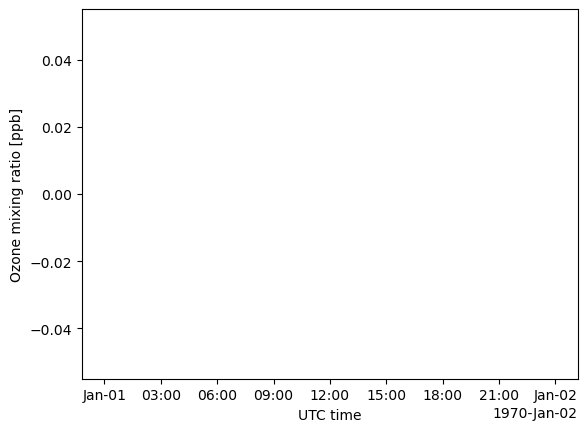

In [4]:
an.open_obs()
an.obs['iagos'].obj['O3_P1'].plot()

### Pair the observations and model data

In [5]:
an.pair_data()

1, in pair data


After pairing:  

      longitude  latitude  altitude                time  \
0        8.5760   50.0424      75.3 2023-06-28 16:23:11   
1        8.5729   50.0419      74.4 2023-06-28 16:23:15   
2        8.5697   50.0408      72.5 2023-06-28 16:23:19   
3        8.5657   50.0400      69.2 2023-06-28 16:23:23   
4        8.5618   50.0389      68.0 2023-06-28 16:23:27   
...         ...       ...       ...                 ...   
6082   -63.5036   44.8898     107.3 2023-06-28 23:08:39   
6083   -63.5054   44.8877      89.3 2023-06-28 23:08:43   
6084   -63.5075   44.8858      76.2 2023-06-28 23:08:47   
6085   -63.5094   44.8838      81.4 2023-06-28 23:08:51   
6086   -63.5113   44.8819      72.2 2023-06-28 23:08:55   

      baro_alt_AC_validity_flag  radio_alt_AC  radio_alt_AC_validity_flag  \
0                           0.0           0.2                         0.0   
1                           0.0           0.1                         0.0   
2                           0.0           0.2               

### Generate plots

Using vertprofile_bins from YAML range: {'start': 0, 'stop': 12000, 'step': 1000}


Value of fill after reading from scatter_density_config: False
Saving scatter density plot to /scratch4/BMC/rcm1/mbruckner/iagos/plot_grp4.scatter_density.CO_P1.2023-06-27_00.2023-06-29_00.all. _iagos_vs_ufsaqm.png...
Processing scatter density plot for model 'ufsaqm' and observation 'iagos'...


Saving scatter density plot to /scratch4/BMC/rcm1/mbruckner/iagos/plot_grp4.scatter_density.CO_P1.2023-06-27_00.2023-06-29_00.all. _iagos_vs_ufsaqm.png...


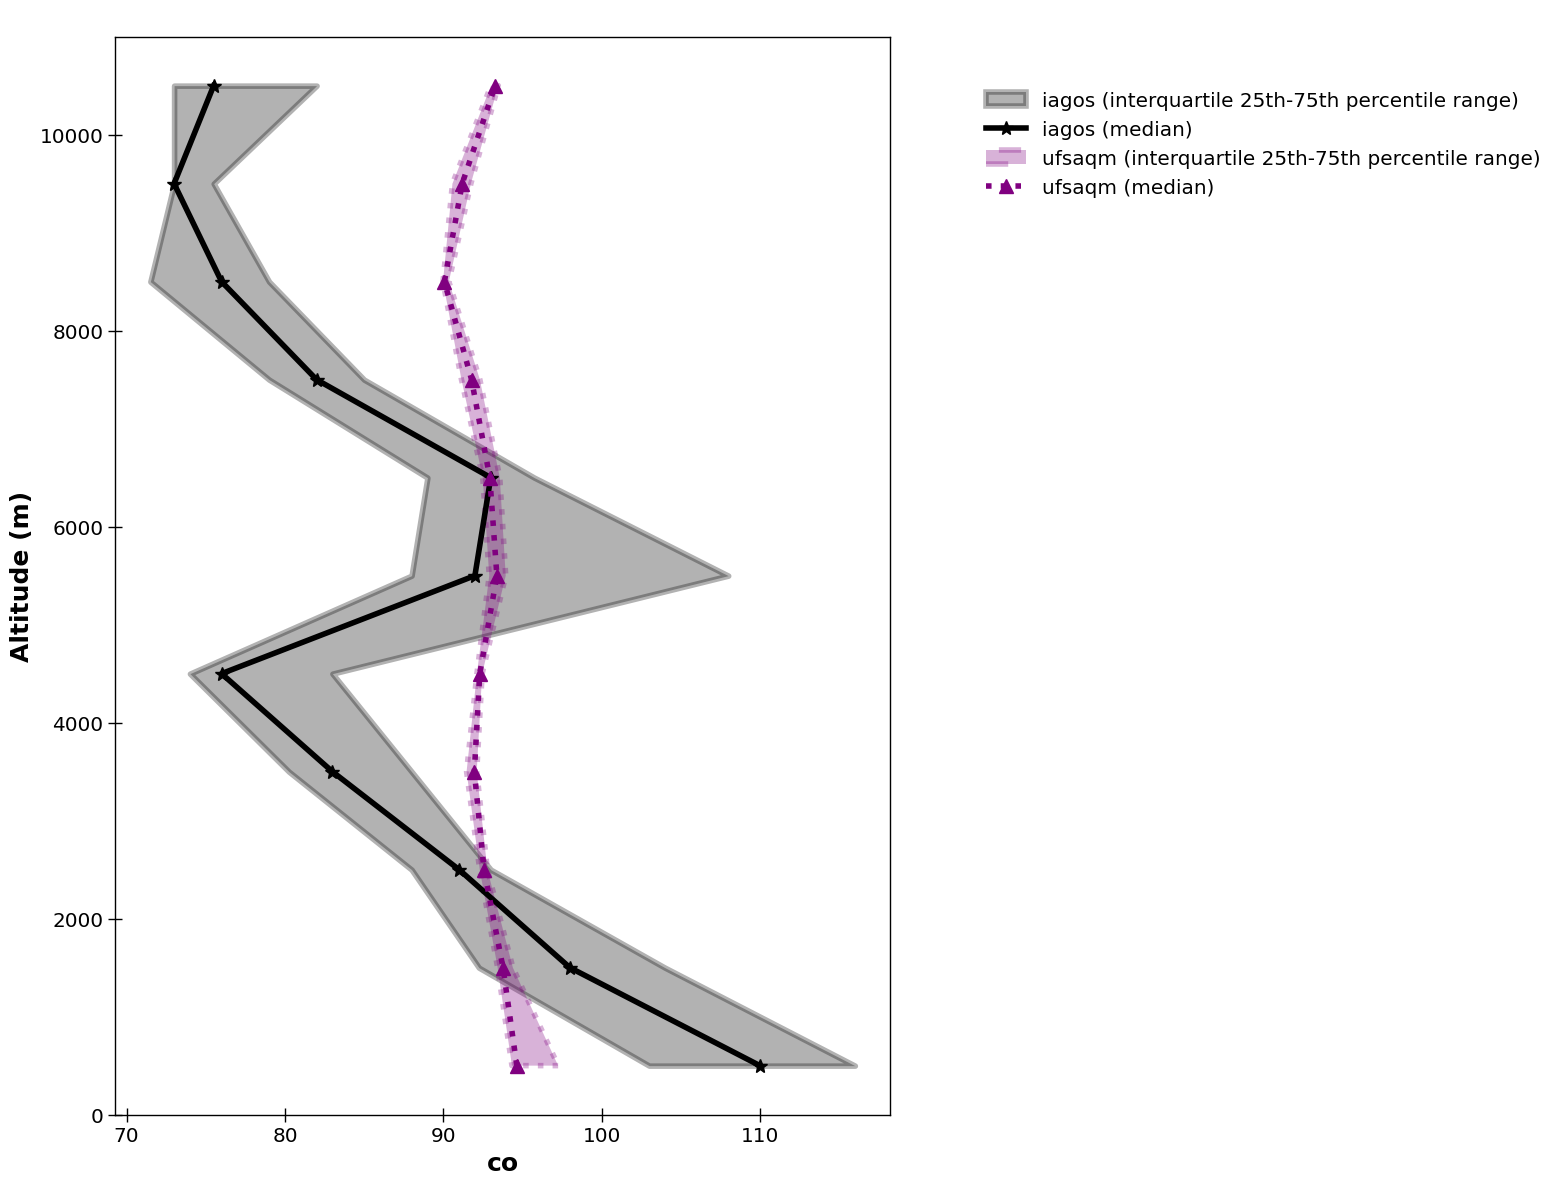

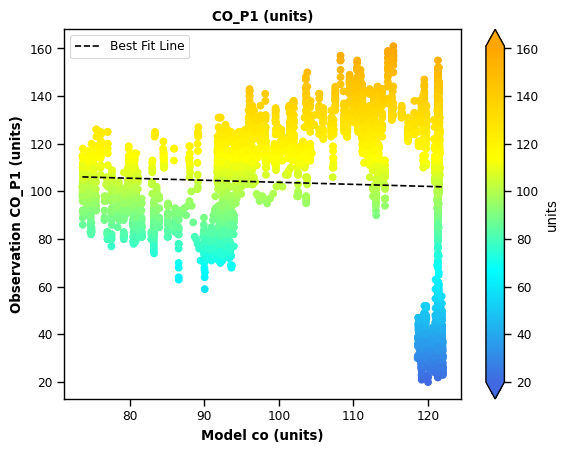

Pressure MIN:<xarray.DataArray 'pressure_model' ()> Size: 8B
array(37.91507721), max: <xarray.DataArray 'pressure_model' ()> Size: 8B
array(103083.58378689), ytick_interval: 100, interpolation_levels: 100  
Saving curtain plot to /scratch4/BMC/rcm1/mbruckner/iagos/plot_grp5.curtain.CO_P1.2023-06-27_00.2023-06-29_00.all. _iagos_vs_ufsaqm.png...
time shape: (6087,), ndims: 1
altitude shape: (100,), ndims: 1
model_data_2d shape: (6087, 100), ndims: 2
pairdf shape: (6087, 58), ndims: 2


cmin and cmax set dynamically based on model and observation data to 13.907084933916728 and 335.0


Setting y-axis limits: vmin=50, vmax=1200
Interval value: 100
Calculated y_ticks: [  50  150  250  350  450  550  650  750  850  950 1050 1150]
Saving curtain plot to /scratch4/BMC/rcm1/mbruckner/iagos/plot_grp5.curtain.CO_P1.2023-06-27_00.2023-06-29_00.all. _iagos_vs_ufsaqm.png...


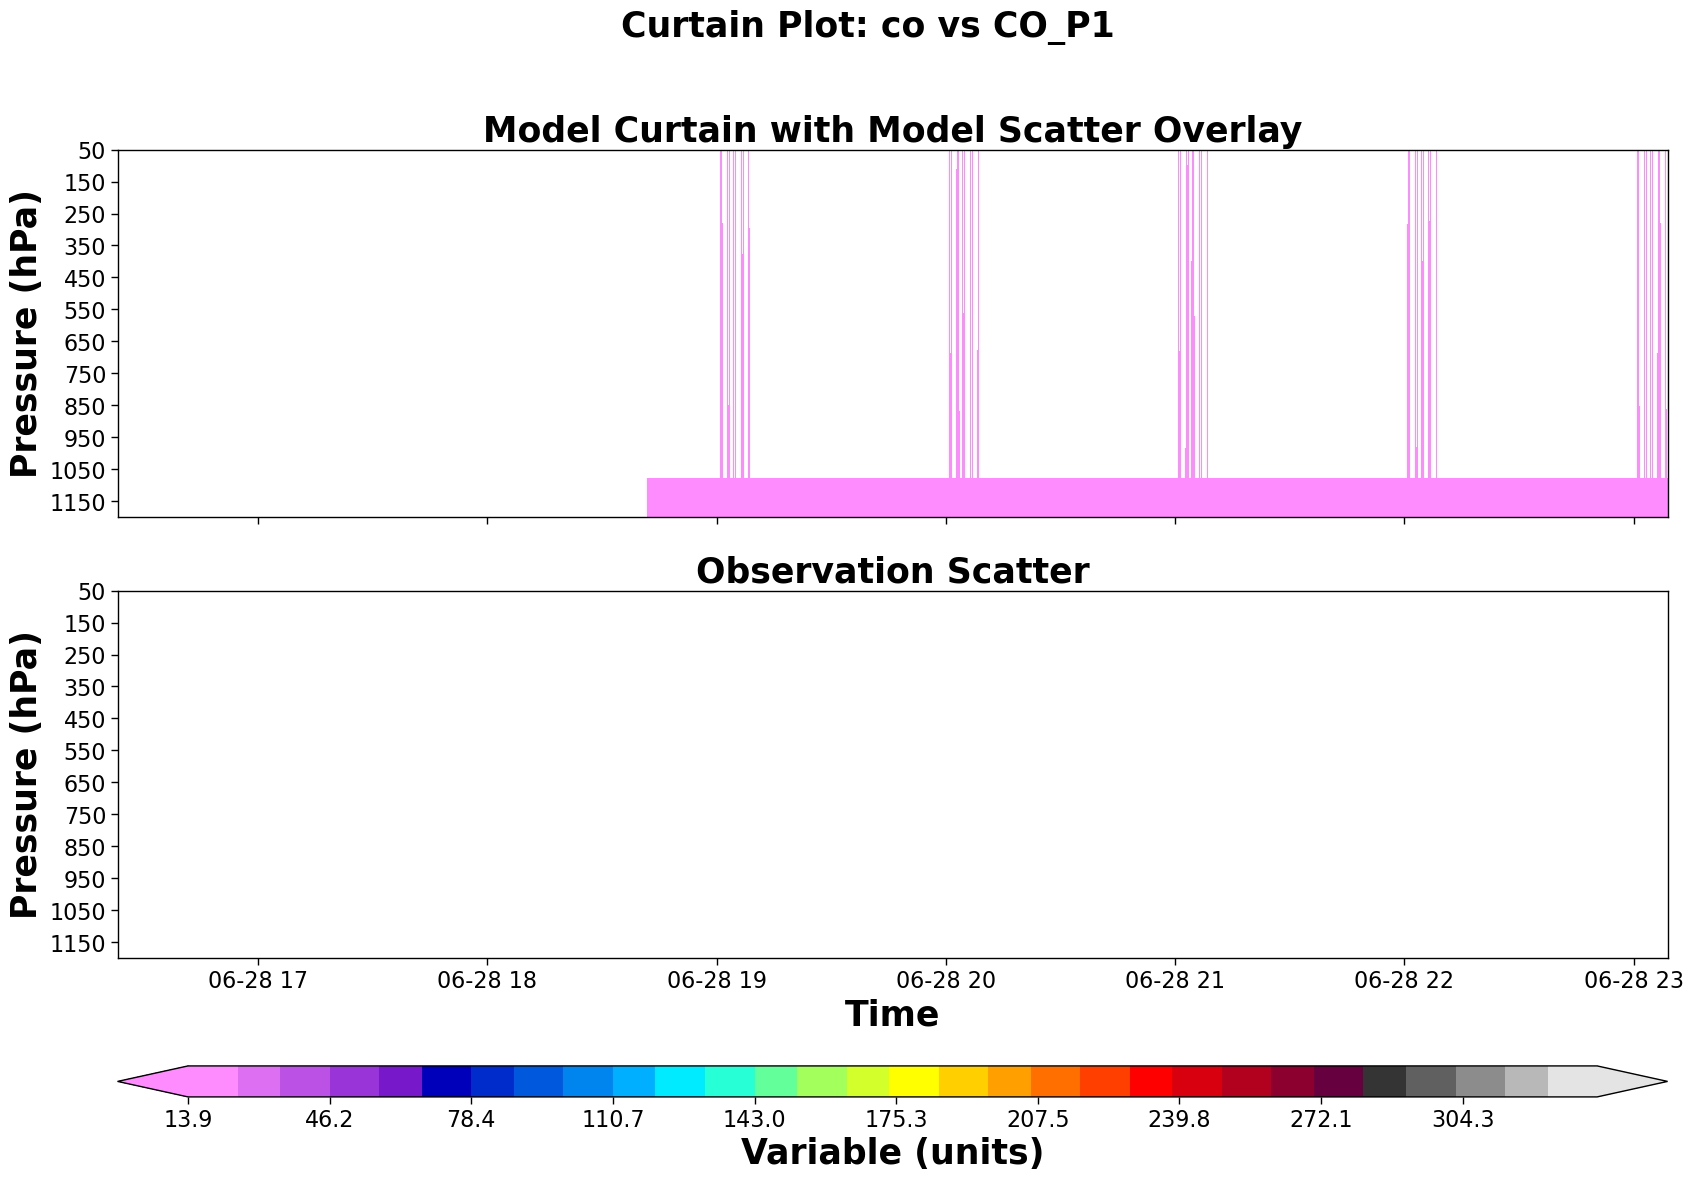

Reference std: 31.054344588303536


In [6]:
an.plotting()